# Лабораторная работа 1

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Загрузим изображение в оттенках серого

Размер изображения: (1024, 1024)


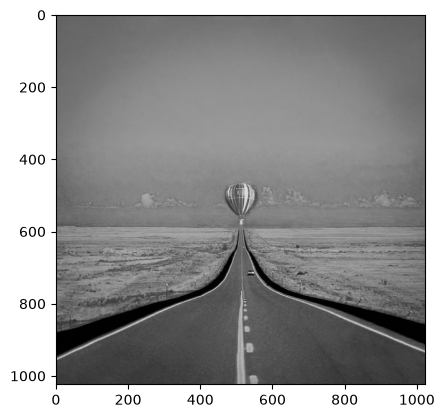

In [30]:
filename = 'airball_grayscale.jpg'

ab_gray = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if ab_gray is None:
    raise FileNotFoundError(f"Не удалось загрузить {filename}")

print("Размер изображения:", ab_gray.shape)
plt.imshow(ab_gray, cmap='gray')
plt.show()

# Построим гистограмму

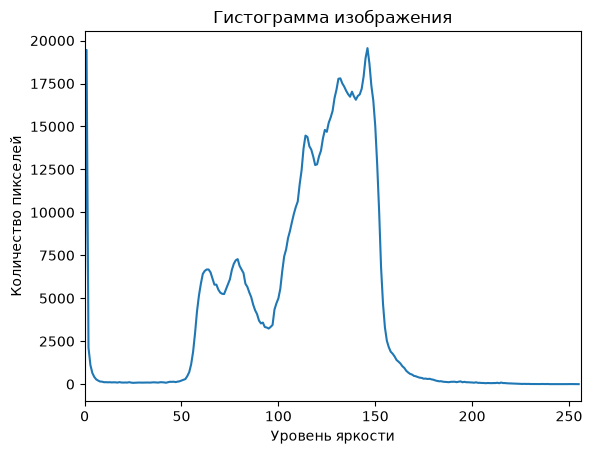

In [8]:
hist = cv2.calcHist(
    [ab_gray],
    [0],
    None,
    [256],
    [0, 256]
)

plt.plot(hist)
plt.title('Гистограмма изображения')
plt.xlabel('Уровень яркости')
plt.ylabel('Количество пикселей')
plt.xlim([0, 256])
plt.show()

# Реализуем функцию гамма-коррекции и протестируем её значениями < 1, > 1, сравним с оригиналом

In [10]:
def gamma_correct(im, gam):
    return np.uint8(np.power(im / 255.0, gam) * 255)

In [12]:
gam_light = 0.3
gam_dark = 1.9

image_gam_light = gamma_correct(
    ab_gray,
    gam_light
)

image_gam_dark = gamma_correct(
    ab_gray,
    gam_dark
)

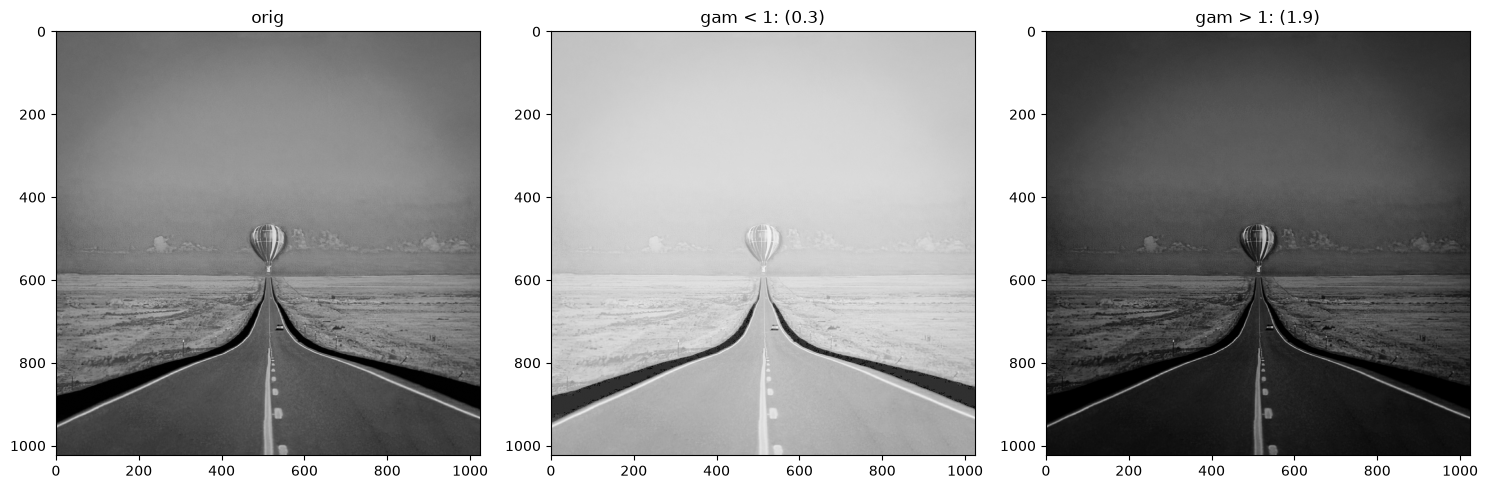

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ab_gray, cmap='gray')
axes[0].set_title('orig')

axes[1].imshow(image_gam_light, cmap='gray')
axes[1].set_title(f'gam < 1: ({gam_light})')

axes[2].imshow(image_gam_dark, cmap='gray')
axes[2].set_title(f'gam > 1: ({gam_dark})')

plt.tight_layout()
plt.show()

# Сравним исходное изображение, скорректированное гамма-фильтром. MSE, SSIM

In [17]:
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error

In [18]:
mse_light = mean_squared_error(
    ab_gray,
    image_gam_light
)

mse_dark = mean_squared_error(
    ab_gray,
    image_gam_dark
)

In [19]:
ssim_light, diff_light = structural_similarity(
    ab_gray,
    image_gam_light,
    full=True
)

ssim_dark, diff_dark = structural_similarity(
    ab_gray,
    image_gam_dark,
    full=True
)

In [20]:
print("ORIG | GAMMA < 1:")
print(f"MSE:  {mse_light:.3f}")
print(f"SSIM: {ssim_light:.3f}")

print()

print("ORIG | GAMMA > 1:")
print(f"MSE:  {mse_dark:.3f}")
print(f"SSIM: {ssim_dark:.3f}")

ORIG | GAMMA < 1:
MSE:  6826.360
SSIM: 0.793

ORIG | GAMMA > 1:
MSE:  3152.485
SSIM: 0.775


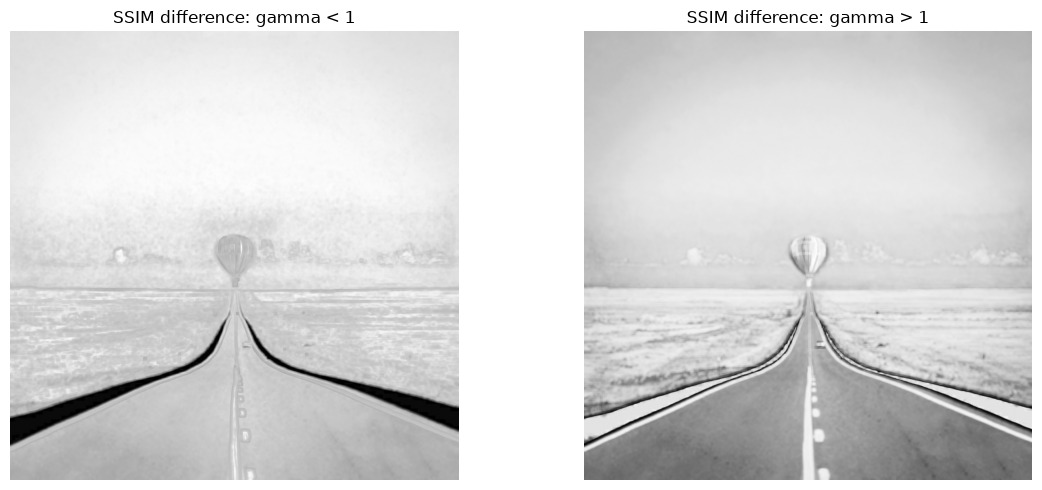

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(diff_light, cmap='gray')
axes[0].set_title('SSIM difference: gamma < 1')
axes[0].axis('off')

axes[1].imshow(diff_dark, cmap='gray')
axes[1].set_title('SSIM difference: gamma > 1')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Алгоритм статической коррекции цвета

In [22]:
def statistical_color_correction(image, reference):
    mean_src = image.mean()
    std_src = image.std()

    mean_ref = reference.mean()
    std_ref = reference.std()

    corrected = (
        (image - mean_src)
        * (std_ref / std_src)
        + mean_ref
    )

    corrected = np.clip(corrected, 0, 255)
    corrected = corrected.astype(np.uint8)

    return corrected

In [24]:
eq_gray = cv2.equalizeHist(ab_gray)

In [25]:
image_corrected = statistical_color_correction(
    ab_gray,
    eq_gray
)

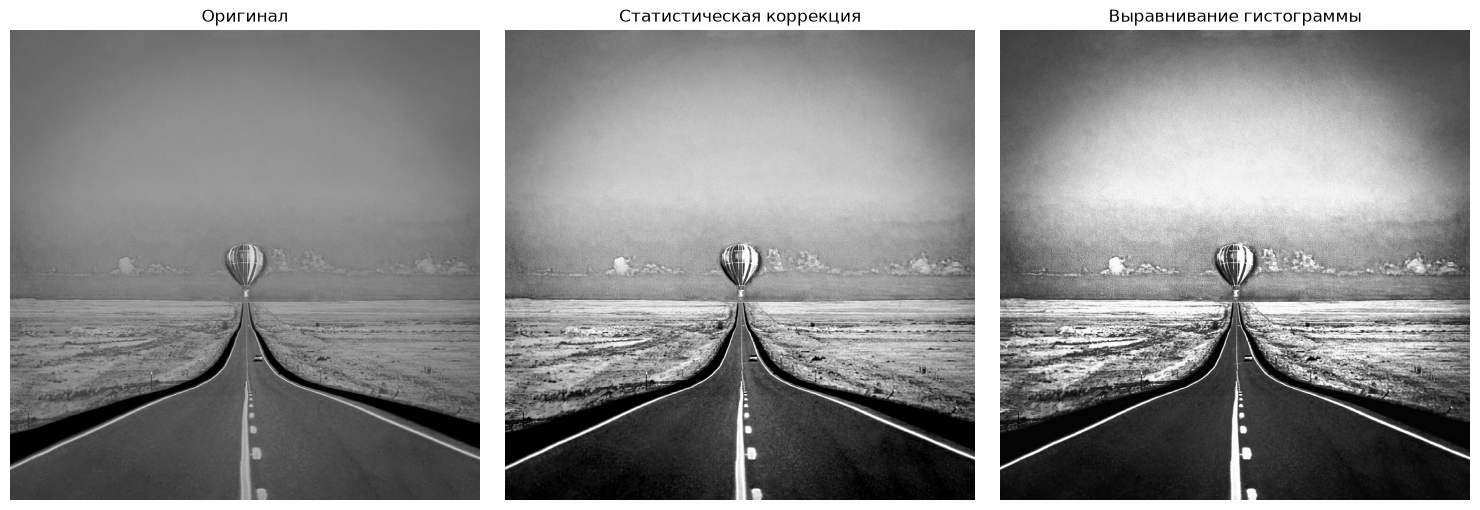

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ab_gray, cmap='gray')
axes[0].set_title('Оригинал')
axes[0].axis('off')

axes[1].imshow(image_corrected, cmap='gray')
axes[1].set_title('Статистическая коррекция')
axes[1].axis('off')

axes[2].imshow(eq_gray, cmap='gray')
axes[2].set_title('Выравнивание гистограммы')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [27]:
ssim_corrected = structural_similarity(
    image_corrected,
    eq_gray
)

mse_corrected = mean_squared_error(
    image_corrected,
    eq_gray
)

print("Статистическая коррекция vs выравнивание гистограммы:")
print(f"SSIM: {ssim_corrected:.3f}")
print(f"MSE:  {mse_corrected:.3f}")

Статистическая коррекция vs выравнивание гистограммы:
SSIM: 0.892
MSE:  396.900


# Протестируем с различными параметрами

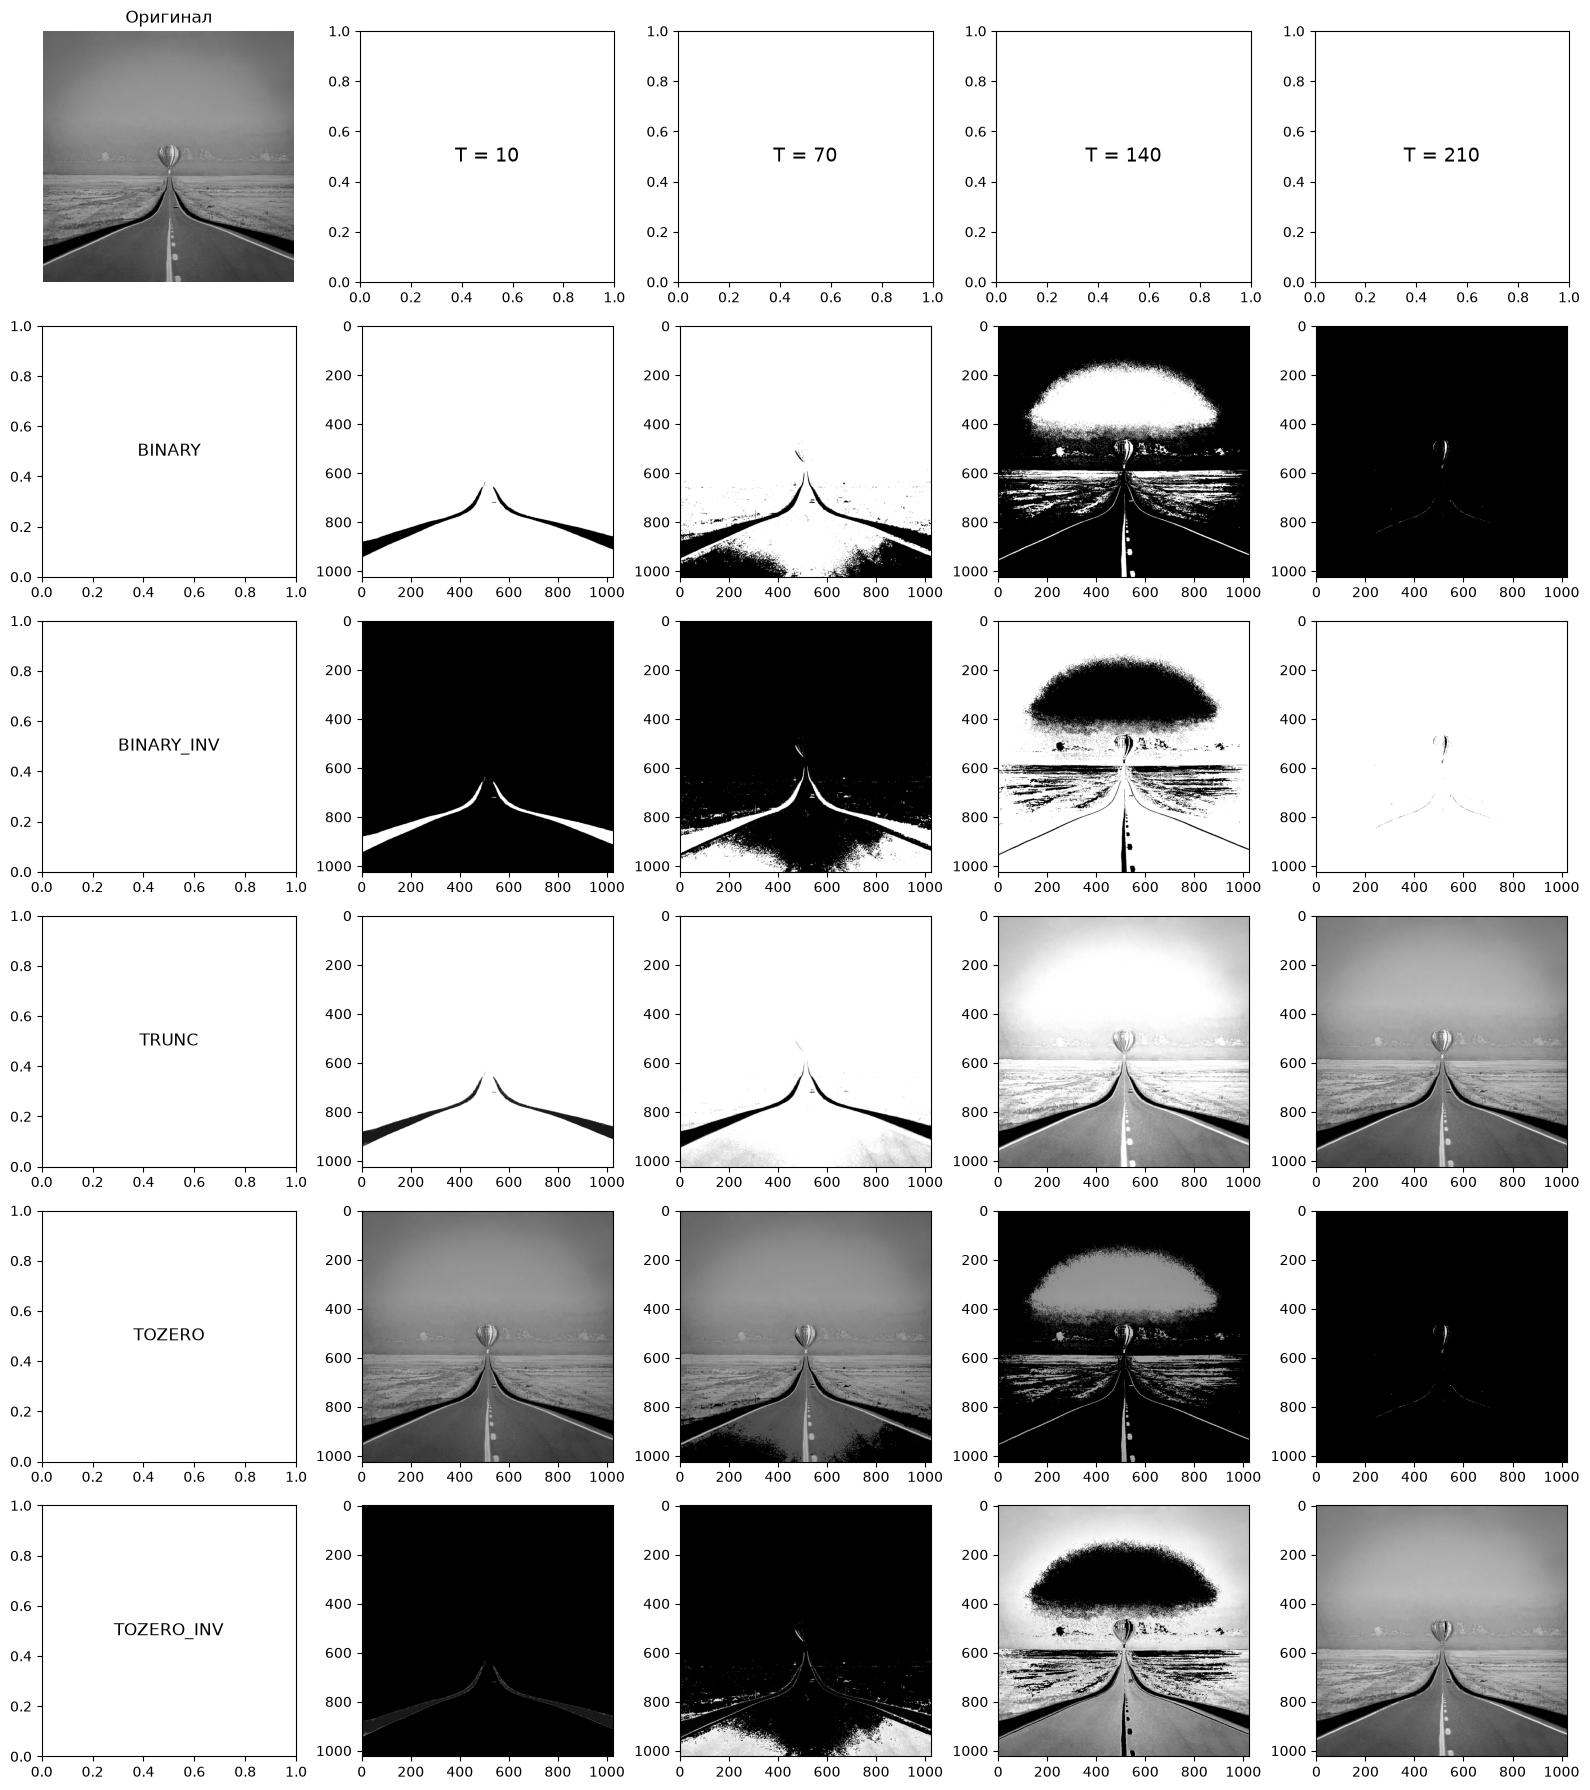

In [34]:
thresholds = [10, 70, 140, 210]

modes = [
    (cv2.THRESH_BINARY, 'BINARY'),
    (cv2.THRESH_BINARY_INV, 'BINARY_INV'),
    (cv2.THRESH_TRUNC, 'TRUNC'),
    (cv2.THRESH_TOZERO, 'TOZERO'),
    (cv2.THRESH_TOZERO_INV, 'TOZERO_INV')
]

fig, axes = plt.subplots(
    len(modes) + 1,
    len(thresholds) + 1,
    figsize=(16, 18)
)

# Исходное изображение
axes[0, 0].imshow(ab_gray, cmap='gray')
axes[0, 0].set_title('Оригинал')
axes[0, 0].axis('off')

# Заголовки столбцов
for j, threshold in enumerate(thresholds):
    axes[0, j + 1].text(
        0.5,
        0.5,
        f'T = {threshold}',
        ha='center',
        va='center',
        fontsize=14
    )

# Фильтрация
for i, (mode, mode_name) in enumerate(modes):

    axes[i + 1, 0].text(
        0.5,
        0.5,
        mode_name,
        ha='center',
        va='center',
        fontsize=12
    )

    for j, threshold in enumerate(thresholds):

        _, result = cv2.threshold(
            ab_gray,
            threshold,
            255,
            mode
        )

        axes[i + 1, j + 1].imshow(
            result,
            cmap='gray'
        )


plt.tight_layout()
plt.show()